In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import cvxpy as cp

In [2]:
DATA_DIR = Path("/Users/sean/code/study-hard/cvx-opt/data")

In [92]:
df = pd.read_csv(DATA_DIR / "winequality-white.csv", sep=';')

In [114]:
df['quality']

0       6
1       6
2       6
3       6
4       6
       ..
4893    6
4894    5
4895    6
4896    7
4897    6
Name: quality, Length: 4898, dtype: int64

In [115]:
df = df[np.logical_and(df['quality'] > 3, df['quality'] < 9)]

In [116]:
n = 11
X = df.iloc[:, :n].to_numpy()
betas = [
    cp.Variable(n),
    cp.Variable(n)
]
y = df.iloc[:, n].to_numpy()
# y = y - np.mean(y)

In [117]:
objectives = [cp.Minimize(cp.norm(y - X @ betas[i], p=p))
             for i, p in enumerate([1,2])]
problems = [cp.Problem(obj) for obj in objectives]
results = [prob.solve() for prob in problems]

In [118]:
y_hats = [X @ beta.value for beta in betas]

In [119]:
results[0]

np.float64(2796.0471976695926)

In [120]:
results[1]

np.float64(51.00609679429364)

In [121]:
import numpy as np

In [122]:
print(np.linalg.norm(y - np.mean(y), ord=1))
print(np.linalg.norm(y - np.mean(y), ord=2))

3198.3168479376154
60.21830454894794


In [123]:
counts, _ = np.histogram(y, bins=[2.5 + i for i in range(8)]) 
count_df = pd.DataFrame({'count': counts, 'fraction': counts / len(y)}, index=np.arange(3, 10))
count_df.index.name = "quality"
print(count_df)

         count  fraction
quality                 
3            0  0.000000
4          163  0.033450
5         1457  0.298994
6         2198  0.451057
7          880  0.180587
8          175  0.035912
9            0  0.000000


In [124]:
for p in [1,2]:
    for i in [0,1]:
        norm_eval = np.linalg.norm(y - X @ betas[i].value, ord=p)
        print(f"||y - X beta_{i+1}||_{p} = {norm_eval}")

||y - X beta_1||_1 = 2796.0471976695926
||y - X beta_2||_1 = 2806.3351328719
||y - X beta_1||_2 = 51.184208788927805
||y - X beta_2||_2 = 51.00609679429364


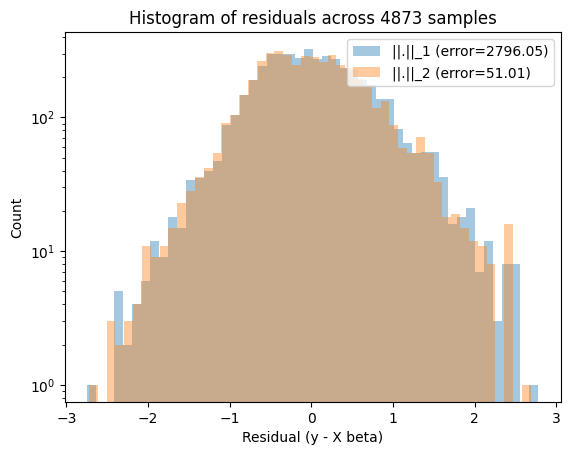

In [127]:
# fig, plots = plt.subplots(2, 1)
fig = plt.figure()
for i, p in enumerate([1,2]):
    plt.hist(y - y_hats[i], bins=50, log=True, alpha=0.4, label=f"||.||_{p} (error={results[i]:.2f})")
plt.title(f"Histogram of residuals across {len(y)} samples")
plt.legend()
plt.xlabel("Residual (y - X beta)")
plt.ylabel("Count")
# plots[1].hist(y, bins=50)
fig.savefig(DATA_DIR / 'histogram_filtered.png')
    
    

In [ ]:
plt.figure()
plt.

In [11]:
help(plots[0].hist)

Help on method hist in module matplotlib.axes._axes:

hist(x, bins=None, *, range=None, density=False, weights=None, cumulative=False, bottom=None, histtype='bar', align='mid', orientation='vertical', rwidth=None, log=False, color=None, label=None, stacked=False, data=None, **kwargs) method of matplotlib.axes._axes.Axes instance
    Compute and plot a histogram.

    This method uses `numpy.histogram` to bin the data in *x* and count the
    number of values in each bin, then draws the distribution either as a
    `.BarContainer` or `.Polygon`. The *bins*, *range*, *density*, and
    *weights* parameters are forwarded to `numpy.histogram`.

    If the data has already been binned and counted, use `~.bar` or
    `~.stairs` to plot the distribution::

        counts, bins = np.histogram(x)
        plt.stairs(counts, bins)

    Alternatively, plot pre-computed bins and counts using ``hist()`` by
    treating each bin as a single point with a weight equal to its count::

        plt.hist(b

(array([   4.,   79.,  317., 1088., 1835., 1299.,  219.,   43.,    9.,
           5.]),
 array([-3.17623697, -2.4671743 , -1.75811164, -1.04904898, -0.33998631,
         0.36907635,  1.07813902,  1.78720168,  2.49626434,  3.20532701,
         3.91438967]),
 <BarContainer object of 10 artists>)

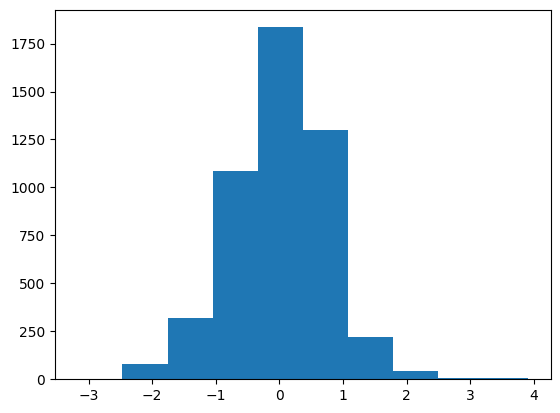

In [59]:
plt.hist(y_hat2 - y)

In [18]:
df.shape

(4898, 12)

In [17]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [ ]:
cp.Variable(

In [15]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7
